In [4]:


!pip install "scikit-learn<1.6.0"
!pip install scikeras


In [ ]:
# 1. Load Fashion-MNIST dataset [cite: 42, 49]
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Class names mapping for Fashion-MNIST [cite: 31, 124]
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Print dataset dimensions before preprocessing [cite: 50, 57]
print("--- Dataset Dimensions Before Preprocessing ---")
print(f"Train images shape: {X_train_raw.shape}")  # Expected: (60000, 28, 28) [cite: 30, 32]
print(f"Test images shape: {X_test_raw.shape}")    # Expected: (10000, 28, 28) [cite: 31, 32]

# Plot 1: Display 10 Sample Images [cite: 51, 94]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]], fontsize=9)
    plt.axis('off')
plt.suptitle("Mandatory Plot 1: Sample Images from Fashion-MNIST")
plt.tight_layout()
plt.show()

# Plot 2: Class Distribution [cite: 52, 95]
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_raw, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Mandatory Plot 2: Class Distribution in Training Set")
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Data Preprocessing [cite: 37, 54]
# Flattening & Normalization [cite: 44, 45, 55, 56]
# Reshape from (28, 28) to 784 feature vector per image and normalize to [0, 1] [cite: 38, 45, 60]
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# Convert labels into one-hot vectors [cite: 46]
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print("\n--- Tensor Shapes After Preprocessing ---")
print(f"Train features shape: {X_train.shape}")  # Expected: (60000, 784)
print(f"Test features shape: {X_test.shape}")    # Expected: (10000, 784)

In [11]:
# ==========================================
# TASK 3 & 4: BASELINE MODEL CONSTRUCTION & TRAINING
# ==========================================

def build_baseline_model():
    # Architecture: 784 -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(10, Softmax) [cite: 27, 59]
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
print("\n--- Baseline Model Summary ---")
baseline_model.summary()  # Display model summary [cite: 64]

# Compile baseline model [cite: 66]
baseline_model.compile(
    optimizer=Adam(),                       # Optimizer: Adam [cite: 67]
    loss='categorical_crossentropy',       # Loss: Categorical Cross Entropy [cite: 68]
    metrics=['accuracy']                   # Metric: Accuracy [cite: 69]
)

# Train the baseline model [cite: 70, 85]
print("\nTraining Baseline Model...")
start_time = time.time()
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,                  # Split data to get validation metrics
    epochs=20,                             # Train for 20 epochs [cite: 70]
    batch_size=32,                         # Batch size 32 [cite: 70]
    verbose=1
)
baseline_duration = time.time() - start_time



--- Baseline Model Summary ---


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_98 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Training Baseline Model...
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8181 - loss: 0.5145 - val_accuracy: 0.8524 - val_loss: 0.4103
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8604 - loss: 0.3822 - val_accuracy: 0.8583 - val_loss: 0.3916
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8745 - loss: 0.3420 - val_accuracy: 0.8758 - val_loss: 0.3400
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8836 - loss: 0.3192 - val_accuracy: 0.8720 - val_loss: 0.3485
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8887 - loss: 0.2981 - val_accuracy: 0.8677 - val_loss: 0.3831
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8940 - loss: 0.2845 - val_accuracy: 0.8732 - val_loss: 0.3441
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8982 - loss: 0.2732 - val_accuracy: 0.8871 - val_loss: 0.3167
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accura

In [12]:
# ==========================================
# TASK 5: BASELINE MODEL EVALUATION
# ==========================================

print("\nEvaluating Baseline Model...")
y_pred_baseline_prob = baseline_model.predict(X_test)
y_pred_baseline = np.argmax(y_pred_baseline_prob, axis=1)

# Compute Metrics [cite: 71, 72]
acc_b = accuracy_score(y_test_raw, y_pred_baseline)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_test_raw, y_pred_baseline, average='macro')

print(f"Baseline Accuracy: {acc_b:.4f}")
print(f"Baseline Precision: {prec_b:.4f}")
print(f"Baseline Recall: {rec_b:.4f}")
print(f"Baseline F1-Score: {f1_b:.4f}")


Evaluating Baseline Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy: 0.8778
Baseline Precision: 0.8820
Baseline Recall: 0.8778
Baseline F1-Score: 0.8790


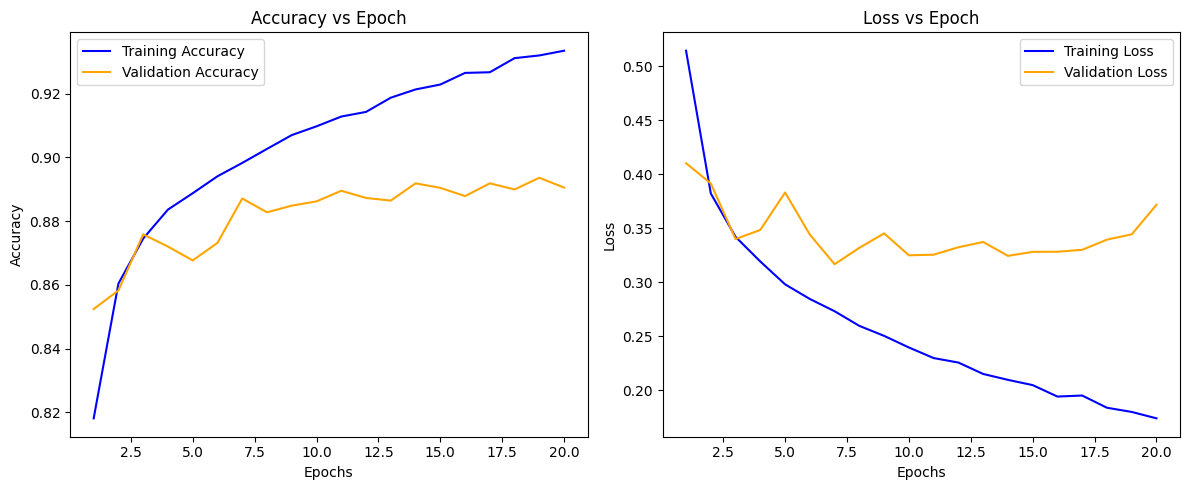

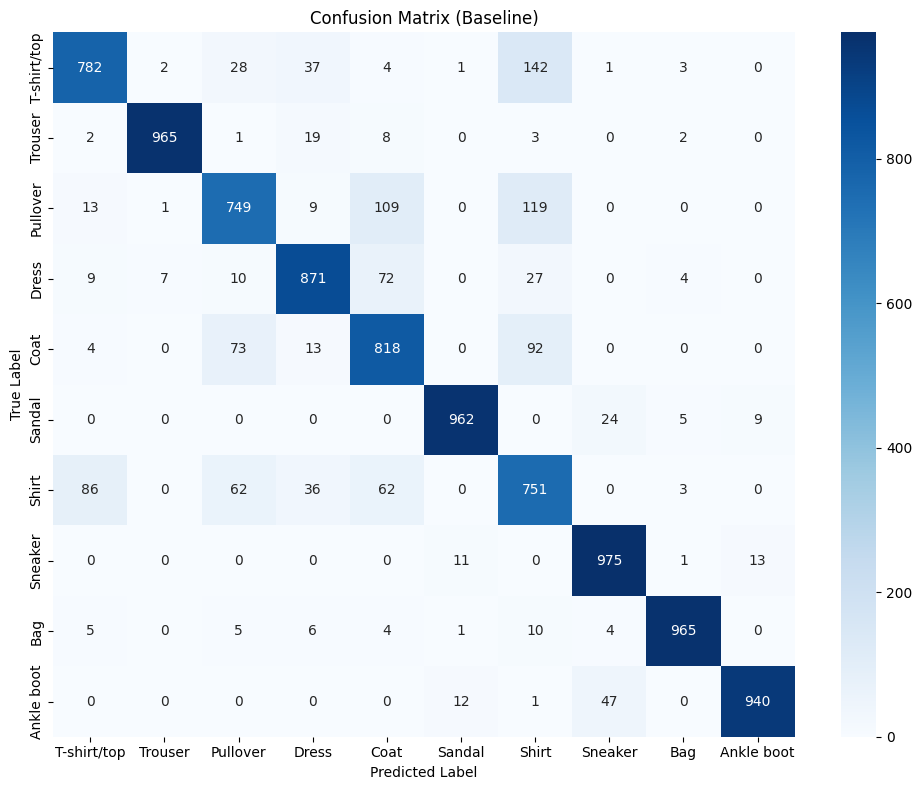

In [13]:
# ==========================================
# MANDATORY PLOTS 3, 4, 5, 6 & 7 (BASELINE)
# ==========================================

epochs_range = range(1, 21)

# Plot 3 & 4: Training & Validation Accuracy vs Epoch [cite: 96, 97]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_baseline.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(epochs_range, history_baseline.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plot 5 & 6: Training & Validation Loss vs Epoch [cite: 98, 99]
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_baseline.history['loss'], label='Training Loss', color='blue')
plt.plot(epochs_range, history_baseline.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 7: Confusion Matrix (Baseline)
cm_baseline = confusion_matrix(y_test_raw, y_pred_baseline)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



Starting Hyperparameter Optimization (RandomizedSearchCV, 5-Fold CV)...
Note: Running a sample iteration subset for speed.

--- Best Hyperparameters Found ---
{'model__optimizer': 'Adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 1, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}


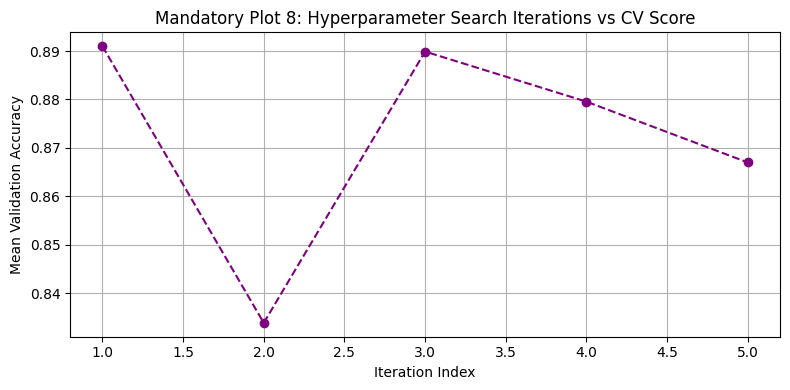

In [14]:
# ==========================================
# AUTOMATED HYPERPARAMETER OPTIMIZATION
# ==========================================

# Dynamically construct model wrapper for SciKeras
def create_tunable_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                         optimizer='Adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))

    # Dynamically scale hidden layers
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    # Select optimizer dynamically
    if optimizer == 'SGD':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'RMSProp':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap model using SciKeras wrapper
keras_clf = KerasClassifier(model=create_tunable_model, verbose=0)

# Define Hyperparameter Search Space [cite: 82, 86]
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer': ['SGD', 'Adam', 'RMSProp'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

# Perform Randomized Search using 5-fold cross-validation
print("\nStarting Hyperparameter Optimization (RandomizedSearchCV, 5-Fold CV)...")
print("Note: Running a sample iteration subset for speed.")
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=5,             # Number of random combinations evaluated
    cv=5,                 # 5-fold cross-validation [cite: 87]
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

# Record the best hyperparameter combination [cite: 88]
best_params = random_search.best_params_
cv_accuracy = random_search.best_score_
print("\n--- Best Hyperparameters Found ---")
print(best_params)

# Plot 8: Hyperparameter Search Results [cite: 101]
plt.figure(figsize=(8, 4))
scores = random_search.cv_results_['mean_test_score']
plt.plot(range(1, len(scores) + 1), scores, marker='o', color='purple', linestyle='dashed')
plt.title("Mandatory Plot 8: Hyperparameter Search Iterations vs CV Score")
plt.xlabel("Iteration Index")
plt.ylabel("Mean Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


Retraining the Model with Optimized Hyperparameters...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


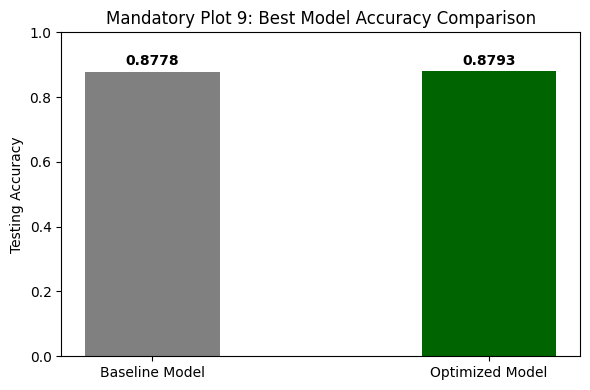

In [15]:
# ==========================================
# RETRAIN AND EVALUATE OPTIMIZED MODEL
# ==========================================

print("\nRetraining the Model with Optimized Hyperparameters...")
# Extract cleanly without wrapper prefix mapping
opt_model = create_tunable_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer=best_params['model__optimizer'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

start_time = time.time()
opt_model.fit(
    X_train, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=0
)
optimized_duration = time.time() - start_time

# Evaluate optimized model [cite: 90]
y_pred_opt_prob = opt_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_opt_prob, axis=1)

acc_o = accuracy_score(y_test_raw, y_pred_opt)
prec_o, rec_o, f1_o, _ = precision_recall_fscore_support(y_test_raw, y_pred_opt, average='macro')

# Plot 9: Best Model Accuracy Comparison [cite: 102]
plt.figure(figsize=(6, 4))
models = ['Baseline Model', 'Optimized Model']
accuracies = [acc_b, acc_o]
plt.bar(models, accuracies, color=['grey', 'darkgreen'], width=0.4)
plt.ylabel('Testing Accuracy')
plt.ylim(0, 1.0)
plt.title("Mandatory Plot 9: Best Model Accuracy Comparison")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
# Print Final Comparison Tables to terminal to map directly to Section 9 [cite: 105, 108]
print("\n===========================================")
print("             MANUAL REPORT TABLES          ")
print("===========================================")
print("\nTable 1: Best Hyperparameters [cite: 106, 107]")
for k, v in best_params.items():
    print(f"{k.split('__')[-1].replace('_', ' ').capitalize()}: {v}")
print(f"Cross-validation Accuracy: {cv_accuracy:.4f}")
print(f"Testing Accuracy: {acc_o:.4f}")

print("\nTable 2: Performance Comparison [cite: 108, 109]")
print(f"{'Metric':<15}{'Baseline':<15}{'Optimized':<15}")
print(f"{'Accuracy':<15}{acc_b:<15.4f}{acc_o:<15.4f}")
print(f"{'Precision':<15}{prec_b:<15.4f}{prec_o:<15.4f}")
print(f"{'Recall':<15}{rec_b:<15.4f}{rec_o:<15.4f}")
print(f"{'F1-score':<15}{f1_b:<15.4f}{f1_o:<15.4f}")
print(f"{'Train Time':<15}{f'{baseline_duration:.2f}s':<15}{f'{optimized_duration:.2f}s':<15}")